# Lab 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
from sklearn.datasets import load_iris

## Examples

In [3]:
x1 = np.arange(6)
x2 = x1 ** 2
X = np.array([[x1[i], x2[i]] for i in range(len(x1))])
X

array([[ 0,  0],
       [ 1,  1],
       [ 2,  4],
       [ 3,  9],
       [ 4, 16],
       [ 5, 25]])

In [4]:
y = np.array([x1[i] + x2[i] for i in range(len(x1))])
y

array([ 0,  2,  6, 12, 20, 30])

In [5]:
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)]).fit(X, y)

In [6]:
y_preds = er.predict(X)
y_preds

array([ 0.,  2.,  6., 12., 20., 30.])

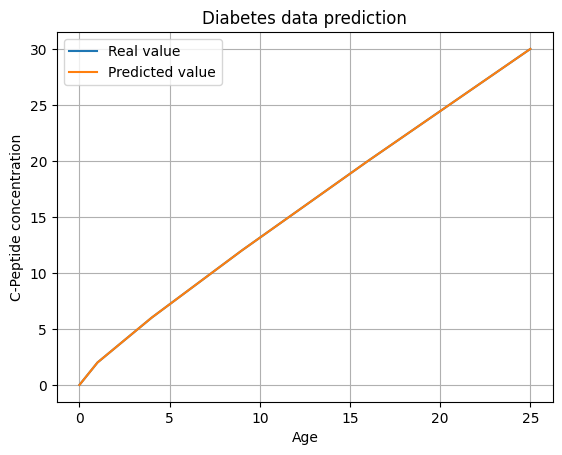

In [7]:
_, ax = plt.subplots()
ax.set(xlabel='Age', ylabel='C-Peptide concentration', title='Diabetes data prediction')
ax.plot(x2, y, label='Real value')
ax.plot(x2, y_preds, label='Predicted value')
ax.grid()
ax.legend()
plt.show()

## Tasks (Version 5)

### 1. Fit the target using Linear Regression

#### Loading data

In [19]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [20]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['class'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


#### One-hot encoding the class variable

In [21]:
df = pd.get_dummies(df, columns=['class'], prefix='class')
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class_0,class_1,class_2
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


In [22]:
feature_names = [i for i in iris.feature_names if 'sepal length' not in i]
feature_names.extend(['class_0', 'class_1', 'class_2'])
X = df[feature_names]
y = df['sepal length (cm)']
X

,sepal width (cm),petal length (cm),petal width (cm),class_0,class_1,class_2
0,3.5,1.4,0.2,True,False,False
1,3.0,1.4,0.2,True,False,False
2,3.2,1.3,0.2,True,False,False
3,3.1,1.5,0.2,True,False,False
4,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...
145,3.0,5.2,2.3,False,False,True
146,2.5,5.0,1.9,False,False,True
147,3.0,5.2,2.0,False,False,True
148,3.4,5.4,2.3,False,False,True


In [23]:
y

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal length (cm), Length: 150, dtype: float64

#### Training

In [24]:
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)])

In [25]:
train_sizes=[0.5, 0.6, 0.7, 0.8, 0.9]

In [26]:
cur_train_size, train_scores, test_scores = learning_curve(er, X, y, train_sizes=train_sizes)

In [27]:
mean_train_scores, mean_test_scores = [], []
for train_size, cv_train_scores, cv_test_scores in zip(cur_train_size, train_scores, test_scores):
    print(f"{train_size} samples:")
    mean_train_scores.append(cv_train_scores.mean())
    mean_test_scores.append(cv_test_scores.mean())
    print(f"Avg train accuracy = {cv_train_scores.mean():.2f}")
    print(f"Avg test accuracy = {cv_test_scores.mean():.2f}")

60 samples:
Avg train accuracy = 0.80
Avg test accuracy = 0.10
72 samples:
Avg train accuracy = 0.79
Avg test accuracy = 0.53
84 samples:
Avg train accuracy = 0.84
Avg test accuracy = 0.56
96 samples:
Avg train accuracy = 0.85
Avg test accuracy = 0.57
108 samples:
Avg train accuracy = 0.86
Avg test accuracy = 0.55


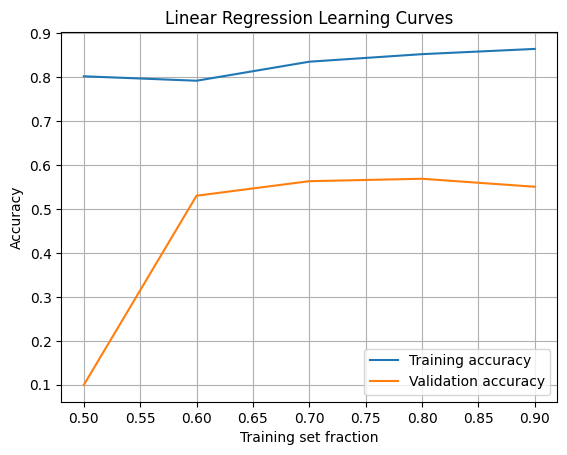

In [28]:
_, ax = plt.subplots()
ax.set(xlabel='Training set fraction', ylabel='Accuracy', title='Linear Regression Learning Curves')
ax.plot(train_sizes, mean_train_scores, label='Training accuracy')
ax.plot(train_sizes, mean_test_scores, label='Validation accuracy')
ax.grid()
ax.legend()
plt.show()

#### Investigating why the results are bad for Linear Regression

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)])
y_preds = er.fit(X_train, y_train).predict(X_test)

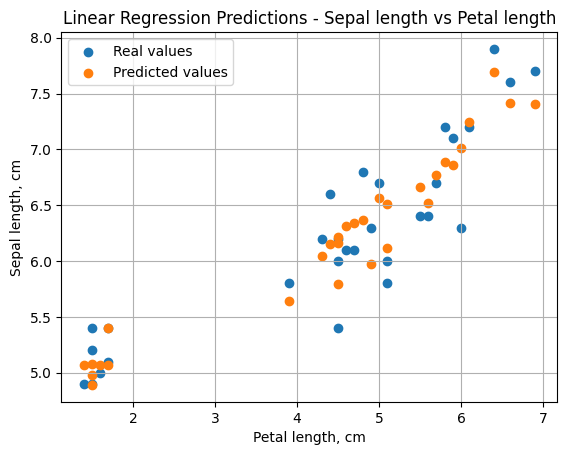

In [30]:
_, ax = plt.subplots()
ax.set(xlabel='Petal length, cm', ylabel='Sepal length, cm',
       title='Linear Regression Predictions - Sepal length vs Petal length')
ax.scatter(X_test['petal length (cm)'], y_test, label='Real values')
ax.scatter(X_test['petal length (cm)'], y_preds, label='Predicted values')
ax.grid()
ax.legend()
plt.show()

### 2. Fit the target using Polynomial Regression

In [31]:
from sklearn.preprocessing import PolynomialFeatures

#### Create polynomial features and scale them

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
X_poly

array([[ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        , -0.13197948, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        ,  0.32841405, -1.39706395, ...,  0.5       ,
         0.5       ,  0.5       ],
       ...,
       [ 1.        , -0.13197948,  0.8195957 , ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        ,  0.78880759,  0.93327055, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ]], shape=(150, 28))

In [33]:
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)])

In [34]:
cur_train_size, train_scores, test_scores = learning_curve(er, X_poly, y, train_sizes=train_sizes)

In [35]:
mean_train_scores, mean_test_scores = [], []
for train_size, cv_train_scores, cv_test_scores in zip(cur_train_size, train_scores, test_scores):
    print(f"{train_size} samples:")
    mean_train_scores.append(cv_train_scores.mean())
    mean_test_scores.append(cv_test_scores.mean())
    print(f"Avg train accuracy = {cv_train_scores.mean():.2f}")
    print(f"Avg test accuracy = {cv_test_scores.mean():.2f}")

60 samples:
Avg train accuracy = 0.85
Avg test accuracy = -1.11
72 samples:
Avg train accuracy = 0.83
Avg test accuracy = -0.60
84 samples:
Avg train accuracy = 0.87
Avg test accuracy = -2.58
96 samples:
Avg train accuracy = 0.88
Avg test accuracy = -0.50
108 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.37


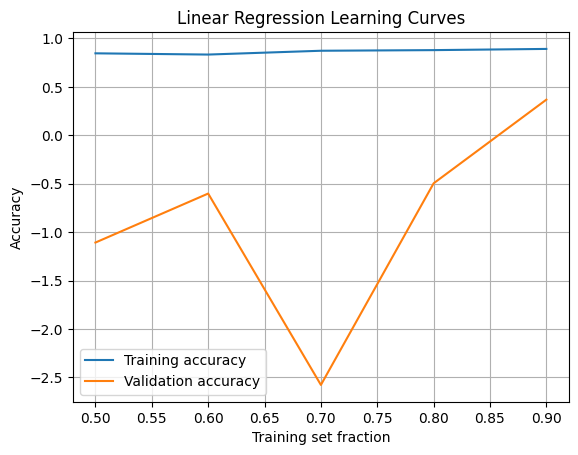

In [36]:
_, ax = plt.subplots()
ax.set(xlabel='Training set fraction', ylabel='Accuracy', title='Linear Regression Learning Curves')
ax.plot(train_sizes, mean_train_scores, label='Training accuracy')
ax.plot(train_sizes, mean_test_scores, label='Validation accuracy')
ax.grid()
ax.legend()
plt.show()

#### Increase the number of samples (just duplicate them)

In [37]:
X_poly = np.repeat(X_poly, 2, axis=0)
X_poly

array([[ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        , -0.13197948, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       ...,
       [ 1.        ,  0.78880759,  0.93327055, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ]], shape=(300, 28))

In [38]:
y = np.repeat(y, 2)
y

0      5.1
0      5.1
1      4.9
1      4.9
2      4.7
      ... 
147    6.5
148    6.2
148    6.2
149    5.9
149    5.9
Name: sepal length (cm), Length: 300, dtype: float64

168 samples:
Avg train accuracy = 0.87
Avg test accuracy = -2.58
192 samples:
Avg train accuracy = 0.88
Avg test accuracy = -0.50
216 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.37
228 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.52
232 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.56
235 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.56
236 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.56
237 samples:
Avg train accuracy = 0.89
Avg test accuracy = 0.56


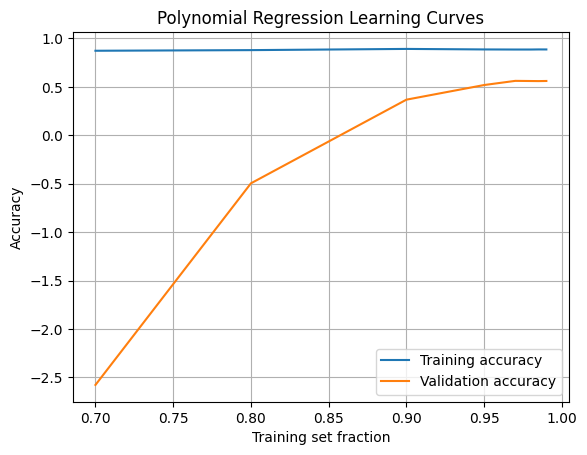

In [39]:
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)])
train_sizes = [0.7, 0.8, 0.9, 0.95, 0.97, 0.98, 0.985, 0.99]
cur_train_size, train_scores, test_scores = learning_curve(er, X_poly, y, train_sizes=train_sizes)
mean_train_scores, mean_test_scores = [], []
for train_size, cv_train_scores, cv_test_scores in zip(cur_train_size, train_scores, test_scores):
    print(f"{train_size} samples:")
    mean_train_scores.append(cv_train_scores.mean())
    mean_test_scores.append(cv_test_scores.mean())
    print(f"Avg train accuracy = {cv_train_scores.mean():.2f}")
    print(f"Avg test accuracy = {cv_test_scores.mean():.2f}")
_, ax = plt.subplots()
ax.set(xlabel='Training set fraction', ylabel='Accuracy', title='Polynomial Regression Learning Curves')
ax.plot(train_sizes, mean_train_scores, label='Training accuracy')
ax.plot(train_sizes, mean_test_scores, label='Validation accuracy')
ax.grid()
ax.legend()
plt.show()

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.1)
r1 = LinearRegression()
er = VotingRegressor([('lr', r1)])
y_preds = er.fit(X_train, y_train).predict(X_test)

ValueError: x and y must be the same size

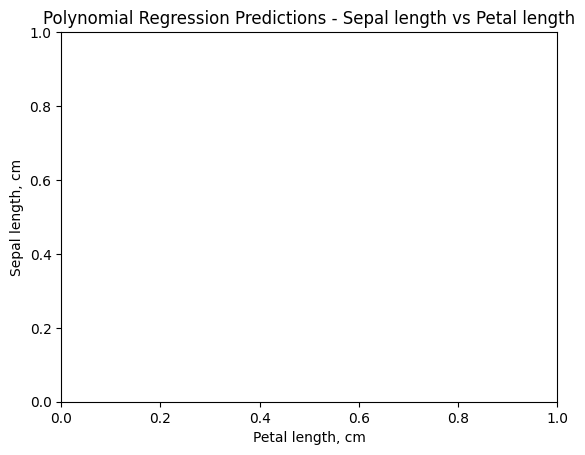

In [41]:
_, ax = plt.subplots()
ax.set(xlabel='Petal length, cm', ylabel='Sepal length, cm',
       title='Polynomial Regression Predictions - Sepal length vs Petal length')
ax.scatter(X_test[2], y_test, label='Real values')
ax.scatter(X_test[2], y_preds, label='Predicted values')
ax.grid()
ax.legend()
plt.show()